In [2]:
#Install and import libraries

# Install packages if you need them
#%pip install pandas
#%pip install seaborn

# Import packages
import pandas as pd
import seaborn as sns

In [3]:
# load the raw data into a dataframe
# your path will be different
# remember to add /work/ at the beginning of the string
raw = pd.read_csv('/work/E2026/ExPsyLing/experiments/masked_prime/data/combined_data.csv')

In [25]:
# make a list of all the columns we want to keep
cols = ['participant_id', 'sender', 'duration', 'prime', 'target', 'condition', 'soa_condition', 'congruence', 'response', 'correct_response']

In [45]:
df = raw[cols]                                                             # make a new dataframe with only the columns in cols
df = df[df['sender'] == 'target']                                          # only keep the "target" rows
df = df[df['condition'] != 'practice']                                     # throw away the practice trials
df.loc[df['target'] == 'BULL', 'correct_response'] = 'n'                   # fix the correct response on "bull"
df['correct'] = (df['response'] == df['correct_response']).astype(int)     # make a new column with 0 or 1 for incorrect / correct
df = df[df['correct'] == 1]                                                # keep only the correct responses   
df = df.rename(columns={'soa_condition': 'soa', 'duration': 'rt'})         # rename the soa and duration columns, just to look nicer

In [48]:
# find average values for the conditions. I did this slightly wrong in class, as I suspected. This is the right way.
df_grouped = df.groupby(['participant_id', 'soa', 'congruence'])['rt'].mean().reset_index()

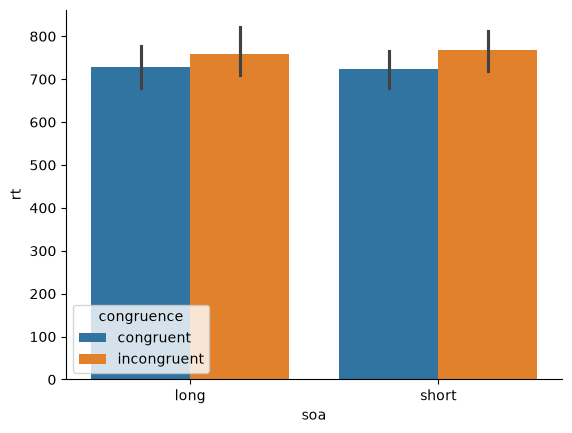

In [53]:
# make barplot of the data.
sns.barplot(data=df_grouped, x='soa', y='rt', hue='congruence')            # make a barplot
sns.despine()                                                              # get rid of the lines around the top and bottom - looks much nicer!